|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Pretrain LLMs<h1>|
|<h2>Lecture:</h2>|<h1><b>Train model 1<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>


In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

# pytorch stuff
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataset import random_split
import torch
import torch.nn as nn
from torch.nn import functional as F

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')


In [2]:
# GPT-2's tokenizer
from transformers import GPT2LMHeadModel, GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")


/home/robertcowher/anaconda3/envs/llm_course/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# use the GPU for speed
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Hyperparameters


In [4]:
# data hyperparameters
seq_len = 8 # context length
stride = 2

# model hyperparameters
embed_dim = 768 # 64

# training hyperparameters
batch_size = 64


# Get data


In [5]:
# tokenize the text and make it a tensor
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)


Token indices sequence length is longer than the specified maximum sequence length for this model (45295 > 1024). Running this sequence through the model will result in indexing errors


45295

### DataLoader


In [6]:
# create a class for a dataset (note: batching is done by the DataLoader, not in the dataset)
class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # initialize
    self.inputs  = []
    self.targets = []

    # overlapping sequences of seq_len
    for i in range(0,len(tokens)-seq_len,stride):

      # get c tokens and append to the lists
      self.inputs.append( tokens[i   : i+seq_len])
      self.targets.append(tokens[i+1 : i+seq_len+1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]


In [7]:
# create an instance!
token_dataset = TokenDataset(tmTokens,seq_len,stride)

train_dataset, test_dataset = random_split(token_dataset, [0.9, 0.1])

# print(len(token_dataset))
# ten_percent = (round(len(token_dataset) / 10))
# print(ten_percent)

# print(len(token_dataset[:]))

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
# next(iter(token_dataloader))


In [8]:
print(len(train_dataset))
print(len(test_dataset))


20380
2264


# The model


In [9]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # embedding matrix
    self.embedding = nn.Embedding(tokenizer.vocab_size,embed_dim)

    # embedding to output (linear) layer
    self.gelu = nn.GELU()
    self.finalLinear = nn.Linear(embed_dim,tokenizer.vocab_size)



  def forward(self,tokx):

    # forward pass
    x = self.embedding(tokx) # [batch, token, embeddings]
    x = self.gelu(x)
    x = self.finalLinear(x) # [embeddings, vocab]

    #n return log-softmax
    return F.log_softmax(x,dim=-1)

  def generate(self,tokx,n_new_tokens=30):
    # mostly same as in DULM_buildGPT_model1 but without comments
    for _ in range(n_new_tokens):
      x = self(tokx)
      x = x[:,-1,:]
      probs = torch.exp(x) #n undo the log but keep the softmax
      nextToken = torch.multinomial(probs,num_samples=1)
      tokx = torch.cat( (tokx,nextToken),dim=1)
    return tokx


### Check the model output


In [10]:
model = Model()
X,y = train_dataset[4]
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape) # confirm torch.sum(torch.exp(out))==1


torch.Size([8])
torch.Size([8])
torch.Size([8, 50257])


In [ ]:
# Copy GPT2 Weights

model.embedding.weight = gpt2.transformer.wte.weight

# Validate the weight copy
# print(model.embedding.weight[0] - gpt2.transformer.wte.weight[0])

# Freezing embedding weights
model.embedding.weight.requires_grad = True

# for name, param in model.named_parameters():
#     print(name)

In [12]:
print(X)
print(y)
print(torch.argmax(out))


tensor([8212,  319,  262,  198,   75, 2419,   13,  632])
tensor([ 319,  262,  198,   75, 2419,   13,  632,  373])
tensor(94433)


# Prepare for training


In [13]:
# push the model to the GPU
model = model.to(device)


In [14]:
# create the loss and optimizer functions
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)


In [15]:
# check loss function with sizes
X,y = next(iter(train_dataset))
log_probs = model(X.to(device))

# print(f'Model input is size:   {X.shape}')
# print(f'Model output is size:  {log_probs.shape}')
# print(f'Target tokens is size: {y.shape}')

# # uh oh...
# loss_function(log_probs[:,:-1,:],y[:,1:].to(device))


In [16]:
# flatten to [batch*token, vocab]
# log_probs_flat = log_probs[:,:-1,:].reshape(-1,log_probs.shape[-1])

# # flatten to a vector
# y_flat = y[:,1:].reshape(-1)

# print(f'Model output is size:  {log_probs_flat.shape}')
# print(f'Target tokens is size: {y_flat.shape}')

# # Now compute the loss
# loss = loss_function(log_probs_flat, y_flat.to(device))
# print('\nLoss:',loss)


In [17]:
# some model generated text (compare with post-training)

# needs to be a tensor with one batch
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# text generation
Y = model.generate(startToks.to(device))
print(tokenizer.decode(Y[0].tolist()))


I thought the Eloi would be smarter than ruiningseeingributionans listing nostalgic Journal gene LCD hereditary synerg knights vol Blackhawks freak protracted goblins skipsid ├ unp Jou Literature Finnish 9000 Kylereditation daughter ED Benjamin


# Now train the model!


In [18]:
num_epochs = 50 

# initialize losses
total_loss = np.zeros(num_epochs)
total_test_loss = np.zeros(num_epochs)



# training loop
for epoch in range(num_epochs):

  # initialize batch losses to accumulate
  epoch_loss = 0
  epoch_test_loss = 0

  # loop over batches in the data loader
  for X,y in train_dataloader:

    # move data to GPU
    X,y = X.to(device), y.to(device)

    # clear previous gradients
    model.zero_grad()

    # forward pass
    log_probs = model(X)

    # calculate the losses on the (reshaped) final target word
    log_probs_flat = log_probs[:,:-1,:].reshape(-1,log_probs.shape[-1]) # tokens 0:N-1
    y_flat = y[:,1:].reshape(-1) # tokens 1:N
    loss = loss_function(log_probs_flat, y_flat)

    # backprop
    loss.backward()
    optimizer.step()

    # sum the batch loss
    epoch_loss += loss.item()

    with torch.no_grad():
      X_test, y_test = next(iter(test_dataloader))
      X_test, y_test = X_test.to(device), y_test.to(device)
      test_log_probs = model(X_test)
      test_log_probs_flat = test_log_probs[:, :-1, :].reshape(-1, test_log_probs.shape[-1])
      y_test_flat = y_test[:, 1:].reshape(-1)

      test_loss = loss_function(test_log_probs_flat, y_test_flat)
      epoch_test_loss += test_loss.item()      

  # scale by the number of tokens in this dataloader
  total_loss[epoch] = epoch_loss / len(train_dataloader)
  total_test_loss[epoch] = epoch_test_loss / len(train_dataloader)
  

  # update our progress :)
  if epoch%2==0:
    print(f'Finished epoch {epoch+1:2} with training loss {epoch_loss / len(train_dataloader):.4f} - test loss: {epoch_test_loss / len(train_dataloader):.4f}')


Finished epoch  1 with training loss 8.5913 - test loss: 8.5769
Finished epoch  3 with training loss 5.6683 - test loss: 5.7803
Finished epoch  5 with training loss 5.1834 - test loss: 5.3876
Finished epoch  7 with training loss 4.8393 - test loss: 5.1115
Finished epoch  9 with training loss 4.5928 - test loss: 4.9028
Finished epoch 11 with training loss 4.4196 - test loss: 4.7486
Finished epoch 13 with training loss 4.2956 - test loss: 4.6290
Finished epoch 15 with training loss 4.2032 - test loss: 4.5430
Finished epoch 17 with training loss 4.1314 - test loss: 4.4616
Finished epoch 19 with training loss 4.0747 - test loss: 4.4078
Finished epoch 21 with training loss 4.0278 - test loss: 4.3543
Finished epoch 23 with training loss 3.9897 - test loss: 4.3032
Finished epoch 25 with training loss 3.9572 - test loss: 4.2785
Finished epoch 27 with training loss 3.9296 - test loss: 4.2464
Finished epoch 29 with training loss 3.9060 - test loss: 4.2296
Finished epoch 31 with training loss 3.8

In [19]:
print(test_dataloader.__len__)

# for X, y in test_dataloader:
#     print(X, y)


<bound method DataLoader.__len__ of <torch.utils.data.dataloader.DataLoader object at 0x76bbf3106840>>


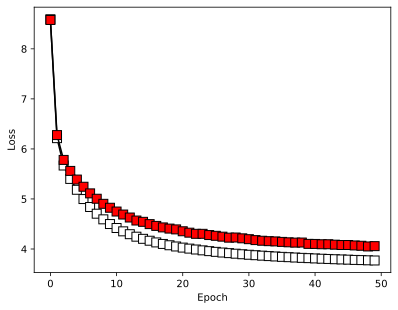

In [20]:
# plot the losses
plt.plot(total_loss,'ks-',markerfacecolor='w',markersize=9)
plt.plot(total_test_loss,'ks-',markerfacecolor='r',markersize=9)
plt.gca().set(xlabel='Epoch',ylabel='Loss')
plt.show()


In [21]:
# theoretical loss for untrained weights
-np.log(1/tokenizer.vocab_size)


np.float64(10.82490511970208)

In [22]:
# check the model output for a training sequence
print(tokenizer.decode(X[6].tolist()))
print(tokenizer.decode(y[6].tolist()))


 I was differently constituted. I came out
 was differently constituted. I came out of


In [23]:
# and generate new topic-related data

# needs to be a tensor with one batch
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# text generation
Y = model.generate(startToks.to(device),n_new_tokens=80)
print(tokenizer.decode(Y[0].tolist()))


I thought the Eloi would be smarter than Upper people sleeping downthe very my and fecity limb It� little gathered, brown flat brittleand was withbrown The rose fell upon optics themachine and machine Everything

escably.
, cast black forb I avent.
�s indeed,the rust stands and
 been away At she
� the or
� last …�
 militant and in of sorts v
yrinth precip


In [24]:
# when the initial text doesn't repeat:
startToks,Y


(tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621]]),
 tensor([[   40,  1807,   262,  2574, 23013,   561,   307, 23714,   621, 20390,
            661, 11029,   866,  1169,   845,   616,   290, 27685,   414, 25035,
            632,   247,  1310,  9272,    11,  7586,  6228, 49307,   392,   373,
            351, 33282,   383,  8278,  3214,  2402, 36237,   262, 30243,   290,
           4572, 11391,   198,   198,  3798,  1346,    13,   198,    11,  3350,
           2042, 11747,   314,   257,  1151,    13,   198,   447,    82,  5600,
             11,  1169, 17000,  6296,   290,   198,   587,  1497,  1629,   673,
            198,   250,   262,   393,   198,   250,   938,  3926,   251,   198,
          18614,   290,   287,   286, 10524,   410,   198, 21324, 18812]],
        device='cuda:0'))

In [25]:
# use this:
print(tokenizer.decode(Y[0].tolist()).replace('\r','\n'))


I thought the Eloi would be smarter than Upper people sleeping downthe very my and fecity limb It� little gathered, brown flat brittleand was withbrown The rose fell upon optics themachine and machine Everything

escably.
, cast black forb I avent.
�s indeed,the rust stands and
 been away At she
� the or
� last …�
 militant and in of sorts v
yrinth precip


In [26]:
# b/c of the carriage return (go to the beginning of the line, not the next line)
tokenizer.decode([201])


'\r'